# Etna Dataset

This notebook builds the Etna case-study dataset for the Cause–Trigger analysis. Waveform features are extracted on an hourly grid, then merged with gas and meteorological context variables. The final dataset is used later for HMML/PCMCI-based trigger analysis.

In [1]:
import sys
from pathlib import Path
from obspy.clients.fdsn import Client

PROJECT_ROOT = Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "src/etna"
sys.path.append(str(SRC_DIR))

from etna_config import (
    ETNA_WAVEFORM_CONFIG,
    ETNA_GAS_METEO_COLS,
    ETNA_EVENT_TIME,
    ETNA_WEATHER_COLS,
    etna_observable_metadata,
)

from etna_waveform import build_station_waveform_dataset

from etna_dataset import (
    load_etnagas_csv,
    extract_plume_co2so2_xls,
    load_etna_event_catalog_xls,
    create_etna_final_dataset,
    load_openmeteo_etna_weather,
)

from etna_plotting_utils import (
    dataset_health_report,
    plot_variable_pdfs,
    distribution_summary,
    run_teleseismic_checks,
    plot_etna_thesis_figures,
    plot_etna_all_variables_map,
    plot_etna_loglog_distributions,
)

from etna_stations import (
    run_station_screening,
    export_station_screening_results,
)

client = Client("INGV")
cfg = ETNA_WAVEFORM_CONFIG
ETNA_STATION = ETNA_WAVEFORM_CONFIG["stations"][0]

import warnings
from obspy.io.mseed import InternalMSEEDWarning

warnings.filterwarnings(
    "ignore",
    category=InternalMSEEDWarning,
    message=r".*fractional second.*10000.*",
)
warnings.filterwarnings(
    "ignore",
    message=r".*fractional seconds.*10000.*",
)


## Etna station availability screening for full analysis window

This section identifies the best Etna seismic station(s) for the full analysis window without downloading the full waveform archive. It first discovers all available vertical channels, then probes a short waveform segment on each day of the study period. Stations are ranked by daily availability and distance to the Etna summit.

Keep `RUN_STATION_SCREENING = False` for normal dataset construction. Set it to `True` only if you want to rerun the reproducible station-selection check and export fresh CSV/TXT reports.


In [2]:
RUN_STATION_SCREENING = False  # Set to True to run station screening, False to skip and use selected station from config

if RUN_STATION_SCREENING:
    streams_found, daily_probe, station_summary = run_station_screening(
        client=client,
        waveform_cfg=ETNA_WAVEFORM_CONFIG,
        max_distance_km=80.0,
        probe_offset_hours=12,
        probe_duration_minutes=10,
        verbose=True,
        display_func=display,
    )

    export_paths = export_station_screening_results(
        station_summary=station_summary,
        daily_probe=daily_probe,
        out_dir="etna_stations",
        waveform_cfg=ETNA_WAVEFORM_CONFIG,
        probe_offset_hours=12,
        probe_duration_minutes=10,
    )

    print("\nRanked station-channel candidates:")
    display(station_summary)

    print("\nBest complete candidates:")
    display(station_summary.query("ok_fraction == 1.0"))

    print("\nSaved station-screening files:")
    for name, path in export_paths.items():
        print(f"{name}: {path}")
else:
    print(
        "Station screening skipped. "
        "Using selected station from ETNA_WAVEFORM_CONFIG: "
        f"{ETNA_STATION}.{ETNA_WAVEFORM_CONFIG['location']}.{ETNA_WAVEFORM_CONFIG['channel']}"
    )

Station screening skipped. Using selected station from ETNA_WAVEFORM_CONFIG: ESLN..HHZ


## Selected station and channel metadata

We inspect the selected ESLN HHZ stream metadata. ESLN was selected because it is close to the Etna summit, has complete retrievable data over the full analysis window, and clearly records the Wenchuan wave arrival.


In [3]:
inventory = client.get_stations(
    network=ETNA_WAVEFORM_CONFIG["network"],
    station=ETNA_STATION,
    location=ETNA_WAVEFORM_CONFIG["location"],
    channel=ETNA_WAVEFORM_CONFIG["channel"],
    level="response",
    starttime=ETNA_WAVEFORM_CONFIG["start"],
    endtime=ETNA_WAVEFORM_CONFIG["end"],
)

print(inventory)

Inventory created at 2026-07-08T05:04:45.287000Z
	Created by: INGV-ONT WEB SERVICE: fdsnws-station | version: 1.1.64
		    /exist/apps/fdsn-station/fdsnws/station/1/query?starttime=2008-04-...
	Sending institution: eXistDB (INGV-ONT)
	Contains:
		Networks (1):
			IV
		Stations (1):
			IV.ESLN (Serra La Nave)
		Channels (1):
			IV.ESLN..HHZ


## Hourly waveform feature extraction

Waveform data are processed in daily chunks with padding for filter stability.


In [4]:
esln_wave, esln_failures = build_station_waveform_dataset(
    client=client,
    station=ETNA_STATION,
    cfg=cfg,
    cache_path="../data/etna/etna_esln_hhz_waveform.pkl",
    redownload=False, #set True to force redownloading, False to use cached dataset
)

print("failures:", esln_failures)
print("shape:", esln_wave.shape)
display(esln_wave.head())
display(esln_wave.tail())
display(esln_wave.isna().mean())

ESLN: loading cached waveform features from ..\data\etna\etna_esln_hhz_waveform.pkl
failures: []
shape: (816, 2)


,teleseismic,background_seismic
time,,
2008-04-12 00:00:00+00:00,1.256462e-05,8.661513e-07
2008-04-12 01:00:00+00:00,4.973278e-06,9.140671e-07
2008-04-12 02:00:00+00:00,9.794816e-06,8.189401e-07
2008-04-12 03:00:00+00:00,8.487838e-07,8.954106e-07
2008-04-12 04:00:00+00:00,1.288926e-05,7.463211e-07


,teleseismic,background_seismic
time,,
2008-05-15 19:00:00+00:00,9.823866e-08,0.000002
2008-05-15 20:00:00+00:00,1.034400e-07,0.000002
2008-05-15 21:00:00+00:00,1.118294e-07,0.000002
2008-05-15 22:00:00+00:00,1.150171e-07,0.000002
2008-05-15 23:00:00+00:00,8.500849e-05,0.000002


teleseismic           0.0
background_seismic    0.0
dtype: float64

## External variables

These variables are merged onto the hourly waveform grid:

- WindSpeed [1] 
- CO2_3 [1] 
- pressure_drop (derived from Patm_3 column) [1]
- plume data (SO2/CO2 ratio) [2]
- Antecedent Precipitation Index (API) (derived from Open-Meteo rainfall data) [3]

[1] Liuzzo, M., Giuffrida, G. B., & Gurrieri, S. (2025). Etna CO2 Soil Flux during 2002-2010 (ECSF2002_2010) [Data set]. Istituto Nazionale di Geofisica e Vulcanologia (INGV). https://doi.org/10.13127/etna/ecsf2002_2010

[2] Aiuppa A., Giudice G., Liuzzo M. (2017). Volcanic gas plume data from Etna Volcano (Italy) (Version 1.0) [Data set]. Interdisciplinary Earth Data Alliance (IEDA). https://doi.org/10.1594/ieda/1006438

[3] Zippenfenig, P. (2023). Open-Meteo.com Weather API [Computer software]. Zenodo. https://doi.org/10.5281/ZENODO.7970649


In [5]:
plume_df = extract_plume_co2so2_xls("../data/etna/1012-1_VolcanicGas_Etna.xls")

In [6]:
etnagas_df = load_etnagas_csv(
    path="../data/etna/3c.csv",
    value_cols=ETNA_GAS_METEO_COLS,
)

display(etnagas_df.head())
display(etnagas_df.isna().mean().sort_values())

,timestamp,CO2_3,pressure_drop,WindSpeed
0,2008-01-18 00:00:00+00:00,0.283836,0.0,0.0
1,2008-01-18 01:00:00+00:00,0.287348,0.0,0.0
2,2008-01-18 02:00:00+00:00,0.274303,0.0,0.0
3,2008-01-18 03:00:00+00:00,0.269285,0.0,0.0
4,2008-01-18 04:00:00+00:00,0.265773,0.0,0.0


timestamp        0.000000
pressure_drop    0.000000
WindSpeed        0.000039
CO2_3            0.002269
dtype: float64

In [7]:
etna_weather_df = load_openmeteo_etna_weather(
    start_date="2008-04-12",
    end_date="2008-05-16",
)

## Effect: Local event rate anomaly

Alparone, S. C., Maiolino, V., Mostaccio, A., Scaltrito, A., Ursino, A., Barberi, G., et al. (2015). Mt. Etna Seismic Catalog 2000-2010 [Data set]. Istituto Nazionale di Geofisica e Vulcanologia (INGV) - Osservatorio Etneo. https://doi.org/10.13127/etnasc/2000_2010

In [8]:
etna_catalog = load_etna_event_catalog_xls(
    "../data/etna/Etna catalogue_2000-2010.xls",
    quality_filter=False,
)

print("Catalogue rows:", len(etna_catalog))
print("Catalogue time range:", etna_catalog["timestamp"].min(), "to", etna_catalog["timestamp"].max())

display(etna_catalog.head())
display(etna_catalog.tail())

Catalogue rows: 6328
Catalogue time range: 2000-01-01 01:21:26+00:00 to 2010-12-31 05:53:46+00:00


,ID,YE,MO,DA,HR,MI,SE,MD,ML,LAT,LON,DEPSL,DEPGL,N.O.,RMS,GAP,ERZ,ERH,timestamp
0,1,2000,1,1,1,21,26,1.3,-,37.794,14.989,6.85,9.19,8,0.05,318,3.2,2.0,2000-01-01 01:21:26+00:00
1,2,2000,1,1,7,39,41,2.1,-,37.643,15.067,1.48,2.26,9,0.13,170,1.0,0.5,2000-01-01 07:39:41+00:00
2,3,2000,1,1,7,44,19,2.6,-,37.643,15.062,0.57,1.38,11,0.12,170,1.1,0.3,2000-01-01 07:44:19+00:00
3,4,2000,1,2,4,15,12,2.7,-,37.645,15.062,1.37,2.21,9,0.13,166,0.9,0.3,2000-01-02 04:15:12+00:00
4,5,2000,1,2,21,22,46,1.1,-,37.713,14.995,4.04,6.40,8,0.05,248,1.1,1.2,2000-01-02 21:22:46+00:00


,ID,YE,MO,DA,HR,MI,SE,MD,ML,LAT,LON,DEPSL,DEPGL,N.O.,RMS,GAP,ERZ,ERH,timestamp
6323,6324,2010,12,25,21,53,52,1.2,1.2,37.713,15.059,3.11,4.80,11,0.07,153,0.4,0.7,2010-12-25 21:53:52+00:00
6324,6325,2010,12,27,0,36,46,1.1,0.9,37.745,15.112,3.89,4.81,15,0.16,80,0.7,0.3,2010-12-27 00:36:46+00:00
6325,6326,2010,12,27,13,34,18,1.4,1.1,37.723,15.052,2.48,4.07,9,0.06,182,1.2,1.6,2010-12-27 13:34:18+00:00
6326,6327,2010,12,30,22,20,16,1.4,1.1,37.683,15.037,4.03,5.52,9,0.08,186,0.5,0.5,2010-12-30 22:20:16+00:00
6327,6328,2010,12,31,5,53,46,1.2,1,37.705,15.070,3.04,4.38,7,0.07,143,0.8,1.5,2010-12-31 05:53:46+00:00


## Merge, scale, and save final hourly datasets

The waveform, gas, meteorological, and plume variables are merged by timestamp. Raw variables are retained, and scaled versions are produced for causal discovery. 

In [9]:
etna_raw, etna_final = create_etna_final_dataset(
    wave_df=esln_wave,
    station_name=ETNA_STATION,
    catalog_df=etna_catalog,
    etnagas_df=etnagas_df,
    etnagas_cols=ETNA_GAS_METEO_COLS,
    plume_df=plume_df,
    weather_df=etna_weather_df,
    weather_cols=ETNA_WEATHER_COLS,
    output_dir="../data/etna"
)


Saved: ..\data\etna\etna_raw.csv
Saved: ..\data\etna\etna_final.csv


## Dataset checks

We check dataset size, timestamp order, duplicate timestamps, missing values, and variable distributions. These checks ensure that the final hourly dataset is suitable for causal discovery.

In [10]:
station_data = {
    ETNA_STATION: {
        "wave": esln_wave,
        "final_raw": etna_raw,
        "final_scaled": etna_final,
    },
}


In [11]:
for sta, d in station_data.items():
    dataset_health_report(d["final_raw"], f"{sta} hourly raw")
    dataset_health_report(d["final_scaled"], f"{sta} hourly scaled")


ESLN hourly raw
shape: (804, 10)
duplicate timestamps: 0
time sorted: True

Missing fraction:
station                     0.0
time                        0.0
teleseismic                 0.0
background_seismic          0.0
local_event_rate_anomaly    0.0
CO2_3                       0.0
pressure_drop               0.0
WindSpeed                   0.0
API                         0.0
CO2_SO2                     0.0
dtype: float64

ESLN hourly scaled
shape: (804, 9)
duplicate timestamps: 0
time sorted: True

Missing fraction:
time                               0.0
teleseismic_scaled                 0.0
background_seismic_scaled          0.0
local_event_rate_anomaly_scaled    0.0
CO2_3_scaled                       0.0
pressure_drop_scaled               0.0
WindSpeed_scaled                   0.0
API_scaled                         0.0
CO2_SO2_scaled                     0.0
dtype: float64


## Distribution diagnostics

Empirical density plots and summary statistics are used to inspect skewness, outliers, and scaling behavior. 


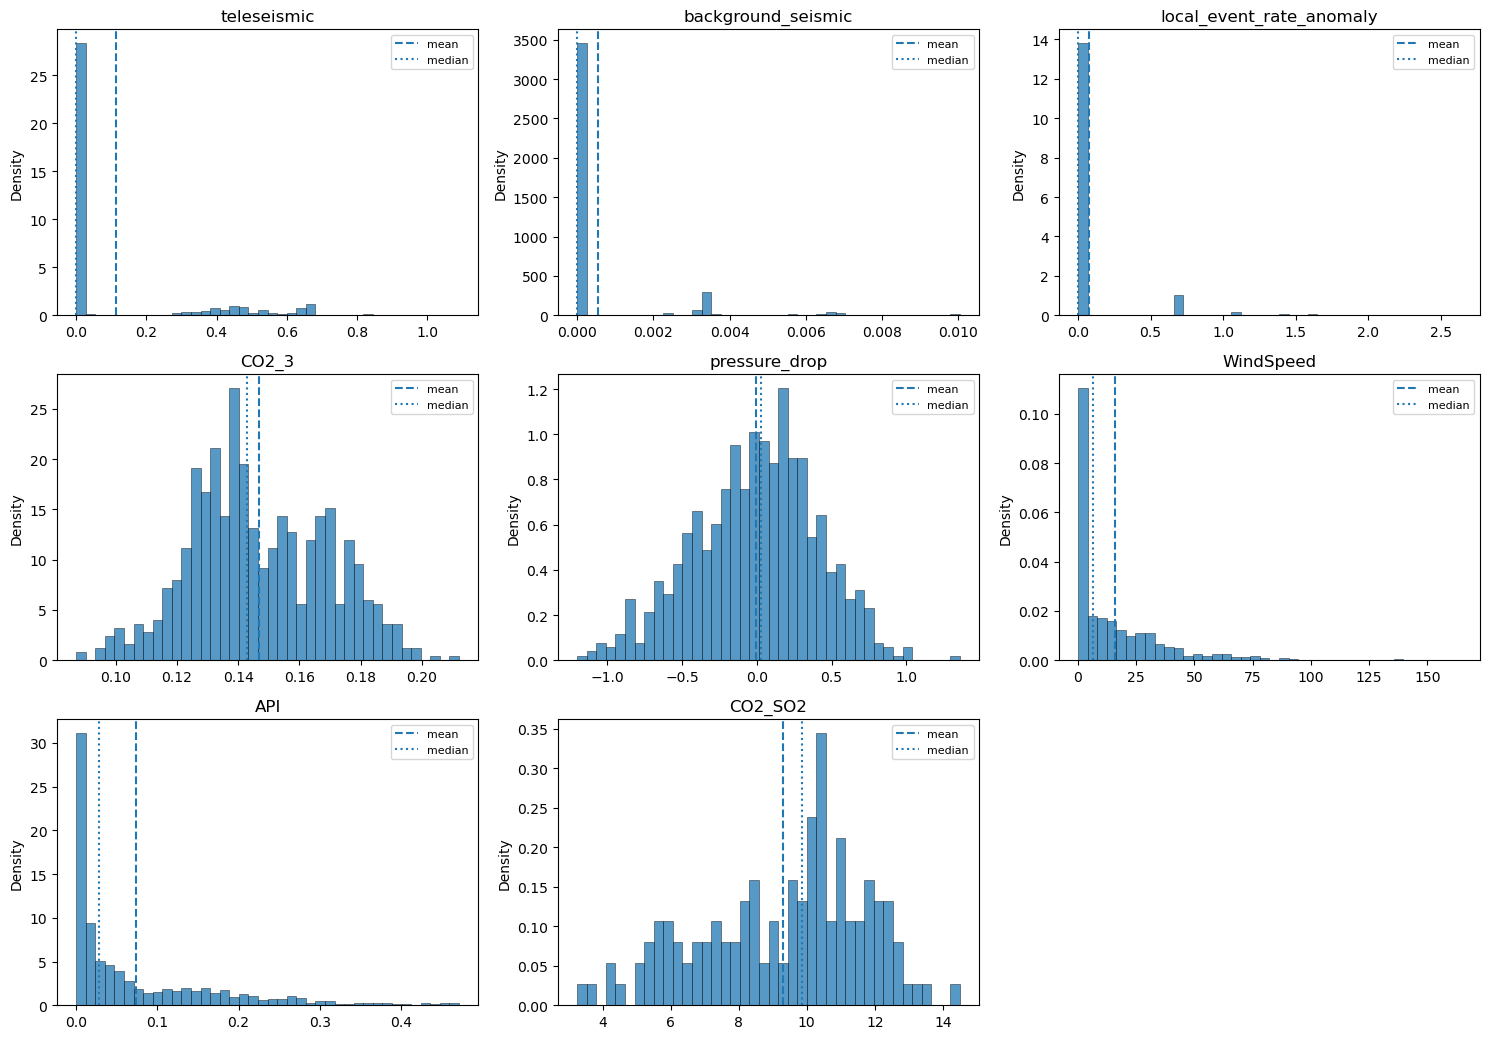

In [12]:
plot_variable_pdfs(etna_raw, filename="etna_pdf.png")

### distribution summary table

In [13]:
summary_esln = distribution_summary(etna_raw)
display(summary_esln)


,count,mean,std,min,median,max,skew,n_unique,missing_fraction
API,804.0,0.073238,0.095732,0.000000e+00,2.787413e-02,0.471235,1.659286,792,0.0
CO2_3,804.0,0.146669,0.022238,8.714800e-02,1.428430e-01,0.212085,0.145580,170,0.0
CO2_SO2,804.0,9.295149,2.405642,3.250000e+00,9.868750e+00,14.500000,-0.426995,116,0.0
WindSpeed,804.0,15.694071,22.112089,0.000000e+00,6.557377e+00,164.344262,2.298024,161,0.0
background_seismic,804.0,0.000544,0.001532,4.844673e-07,1.004955e-06,0.010041,3.201470,557,0.0
local_event_rate_anomaly,804.0,0.075037,0.262341,0.000000e+00,0.000000e+00,2.639057,4.202358,7,0.0
pressure_drop,804.0,-0.005889,0.409092,-1.201602e+00,2.861000e-02,1.358955,-0.199810,295,0.0
teleseismic,804.0,0.114085,0.221928,7.554136e-08,3.123515e-07,1.091039,1.657667,804,0.0


### Etna raw-variable log-log distributions

a visual diagnostic for scale, tails, and zero inflation.

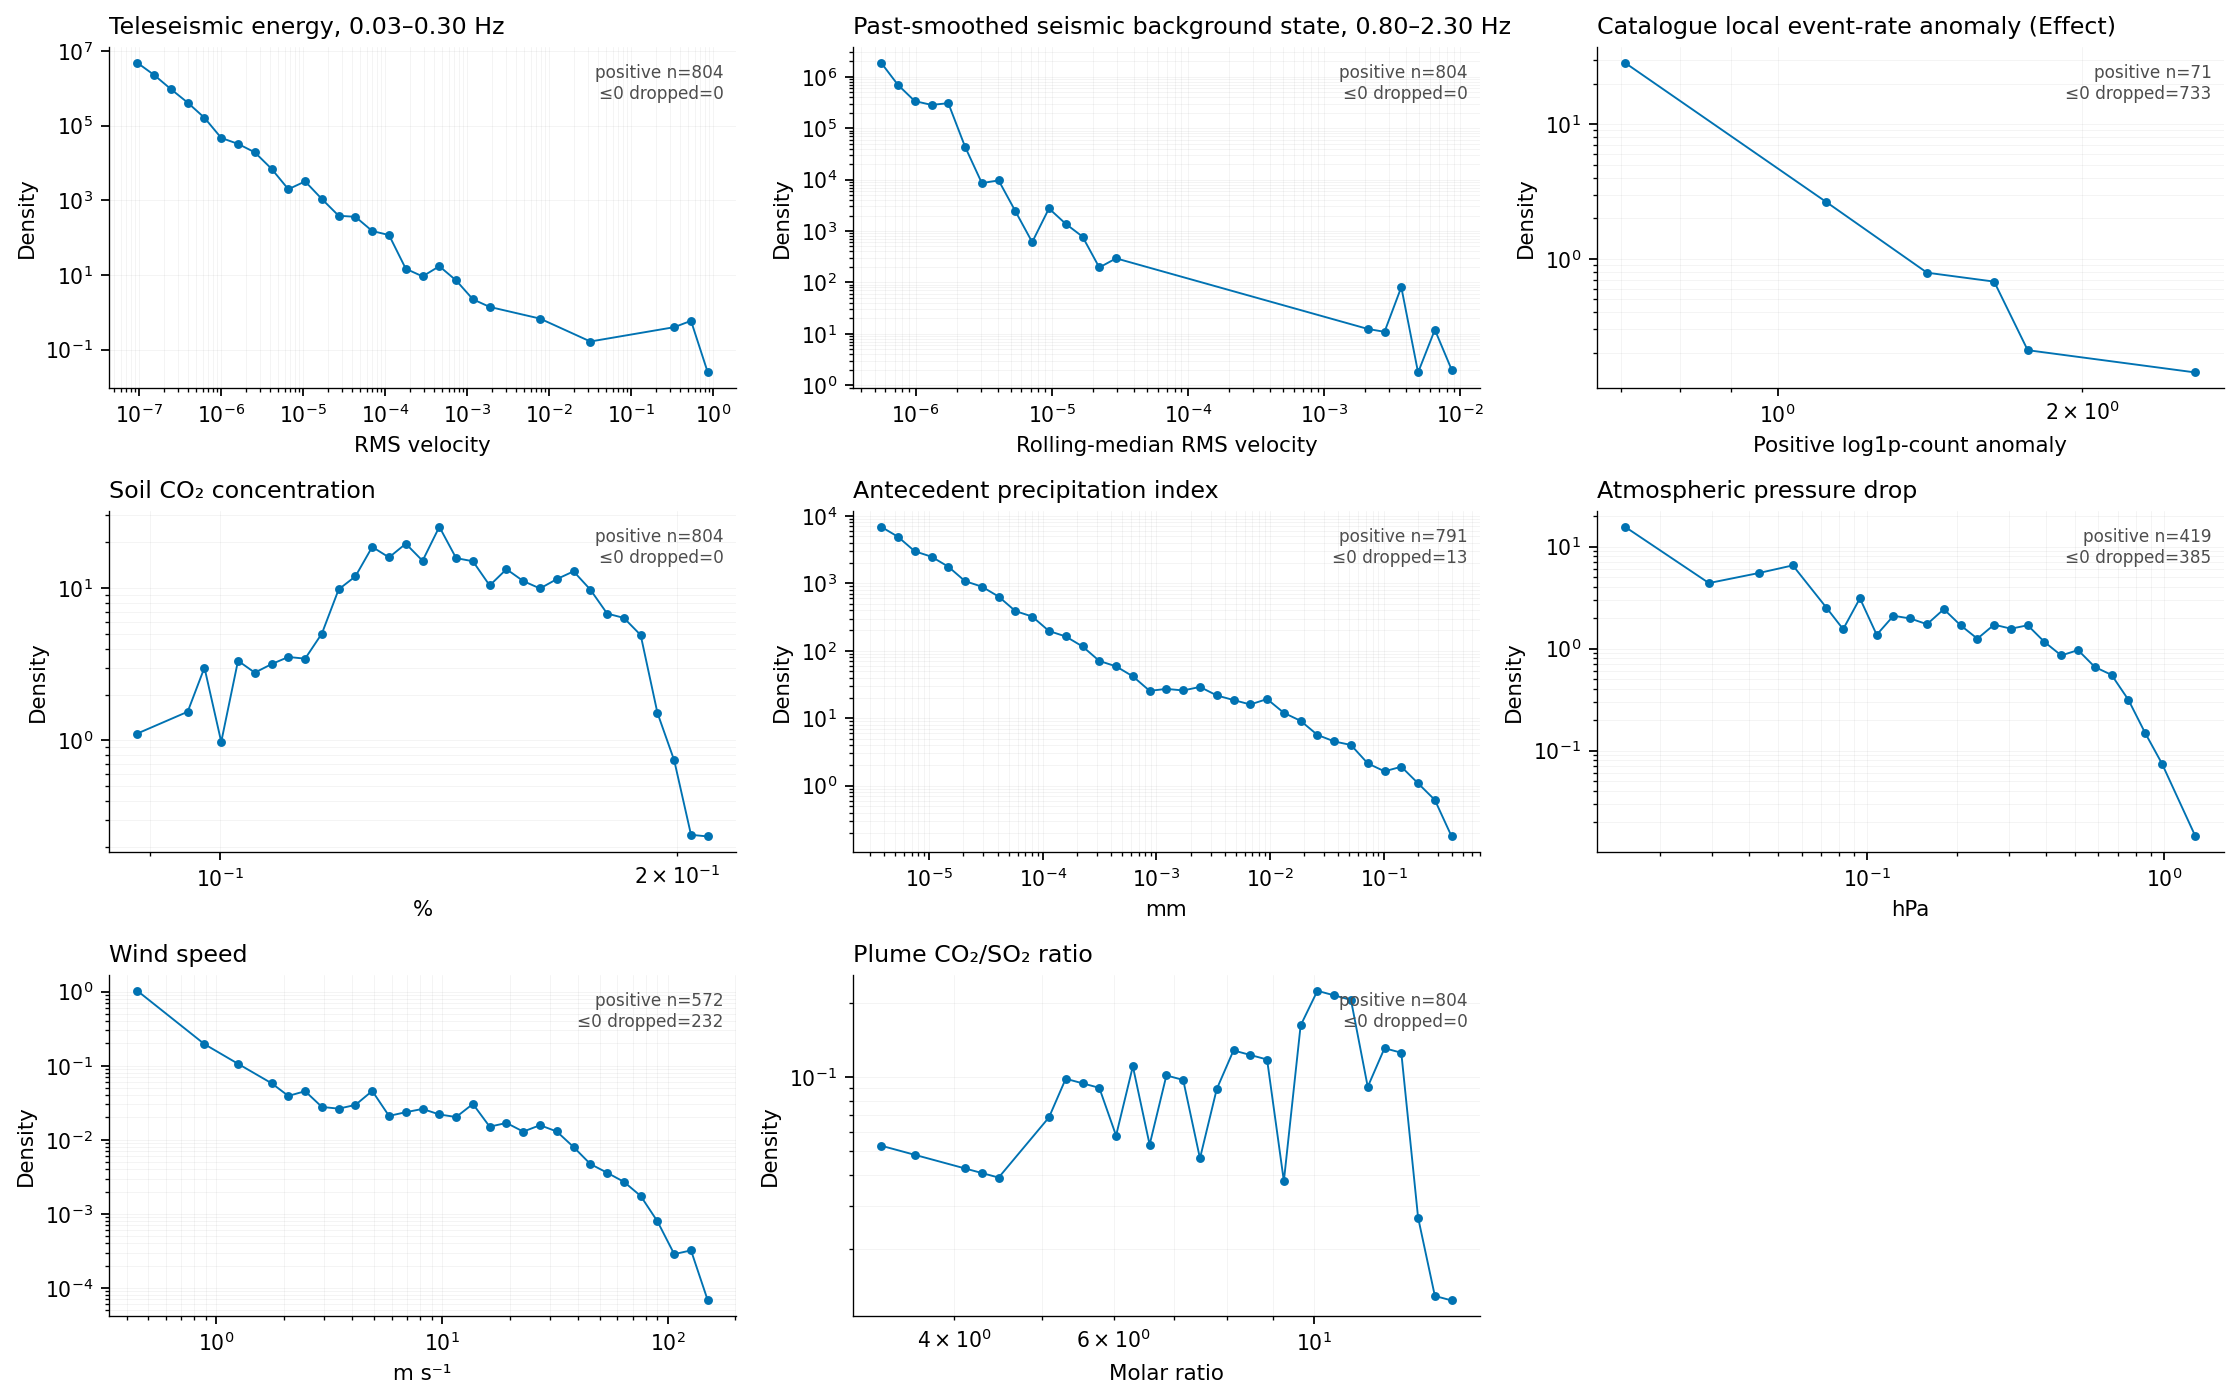

,variable,n_total_nonmissing,n_positive_used,n_nonpositive_dropped,positive_fraction,min_positive,max_positive,n_unique_positive
0,teleseismic,804,804,0,1.000000,7.554136e-08,1.091039,804
1,background_seismic,804,804,0,1.000000,4.844673e-07,0.010041,557
2,local_event_rate_anomaly,804,71,733,0.088308,6.931472e-01,2.639057,6
3,CO2_3,804,804,0,1.000000,8.714800e-02,0.212085,170
4,API,804,791,13,0.983831,3.187129e-06,0.471235,791
5,pressure_drop,804,419,385,0.521144,1.430400e-02,1.358955,143
6,WindSpeed,804,572,232,0.711443,4.098360e-01,164.344262,160
7,CO2_SO2,804,804,0,1.000000,3.250000e+00,14.500000,116


In [14]:
fig, axes, etna_loglog_report = plot_etna_loglog_distributions(
    etna_raw,
    save_dir="figures",
)

display(etna_loglog_report)

In [15]:
model_cols = [c for c in etna_final.columns if c != "time"]
scaled_check = etna_final[model_cols].agg(["mean", "std", "min", "max"]).T
scaled_check["std_ddof0"] = etna_final[model_cols].std(ddof=0)

display(scaled_check)
display(etna_final[model_cols].abs().max().sort_values(ascending=False))

,mean,std,min,max,std_ddof0
teleseismic_scaled,4.860678e-17,1.000622,-0.778988,1.919617,1.0
background_seismic_scaled,7.600333e-16,1.000622,-0.624049,2.847093,1.0
local_event_rate_anomaly_scaled,2.651279e-17,1.000622,-0.286207,9.779688,1.0
CO2_3_scaled,-2.828031e-16,1.000622,-2.743420,2.875218,1.0
pressure_drop_scaled,2.651279e-17,1.000622,-2.639208,2.911837,1.0
WindSpeed_scaled,-7.070077e-17,1.000622,-0.710193,6.726760,1.0
API_scaled,-1.767519e-17,1.000622,-0.800473,3.810545,1.0
CO2_SO2_scaled,8.484092e-16,1.000622,-3.260223,1.683897,1.0


local_event_rate_anomaly_scaled    9.779688
WindSpeed_scaled                   6.726760
API_scaled                         3.810545
CO2_SO2_scaled                     3.260223
pressure_drop_scaled               2.911837
CO2_3_scaled                       2.875218
background_seismic_scaled          2.847093
teleseismic_scaled                 1.919617
dtype: float64

## Teleseismic arrival diagnostics

We inspect the waveform around the Wenchuan earthquake arrival. The 1-minute RMS is compared with hourly maximum aggregation to verify that the hourly grid preserves the teleseismic-arrival energy. The spectrogram is used only to document the waveform-derived trigger and background-state bands; the final Etna effect variable is now derived from the local seismic event catalogue, not from a waveform response band.

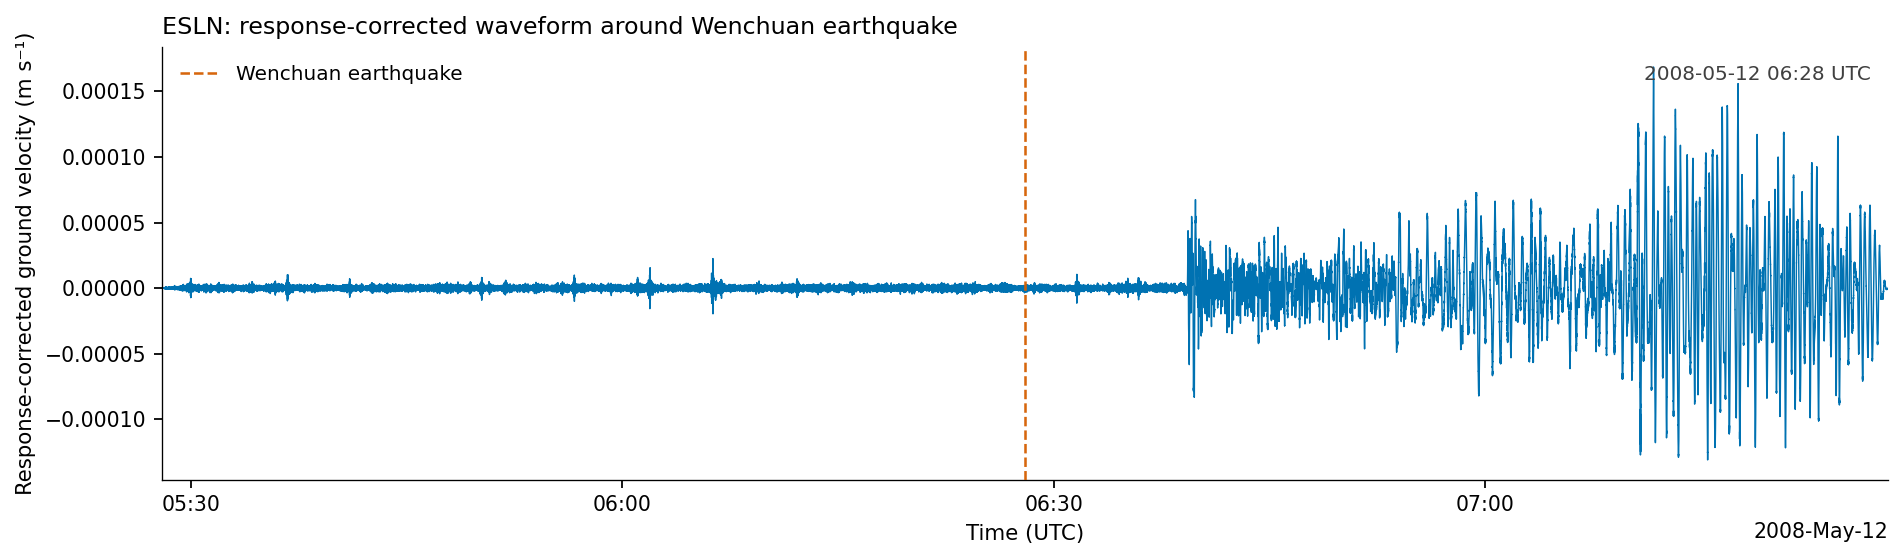

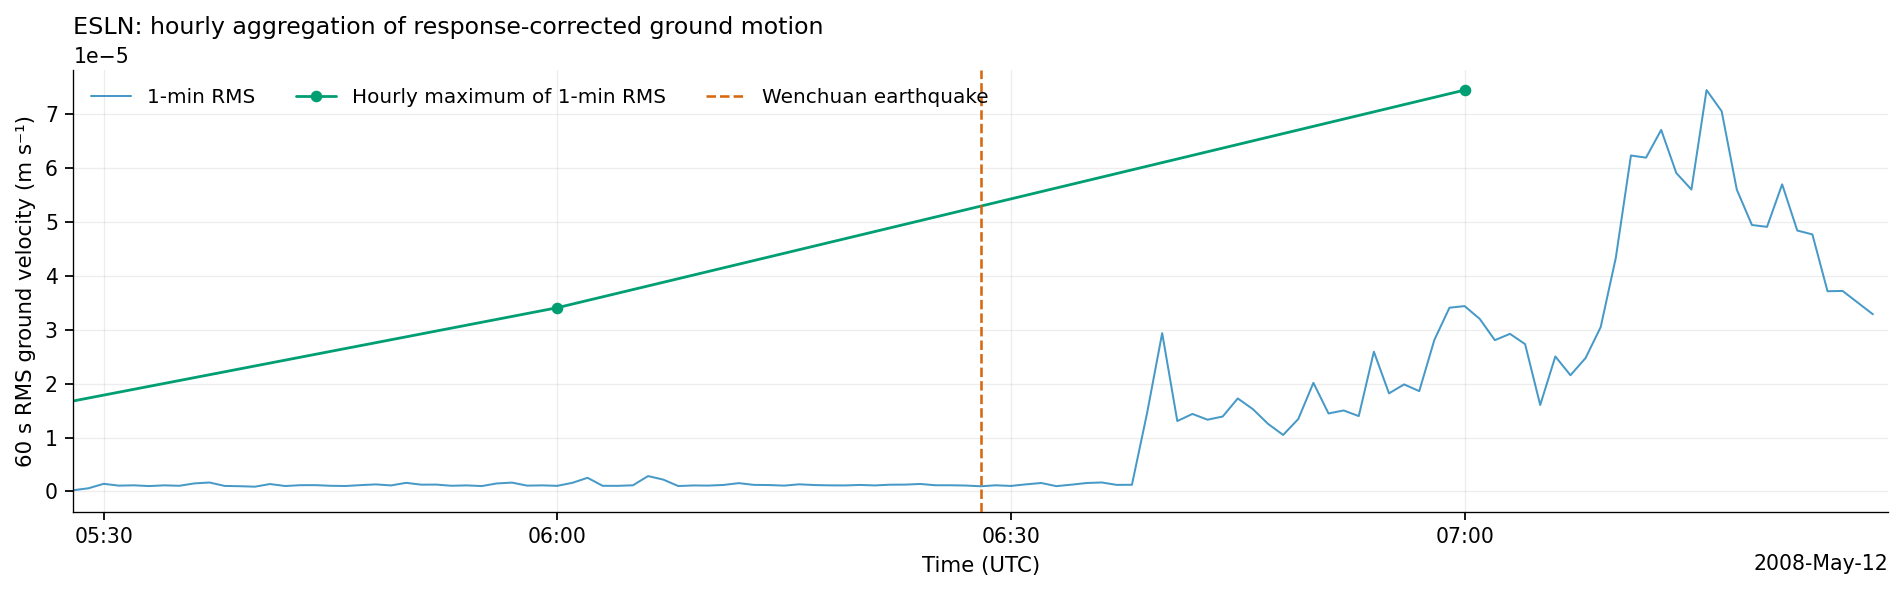


ESLN
1-min peak: 2008-05-12 07:16:00+00:00
hourly peak bin: 2008-05-12 07:00:00+00:00
difference: 0 days 00:16:00


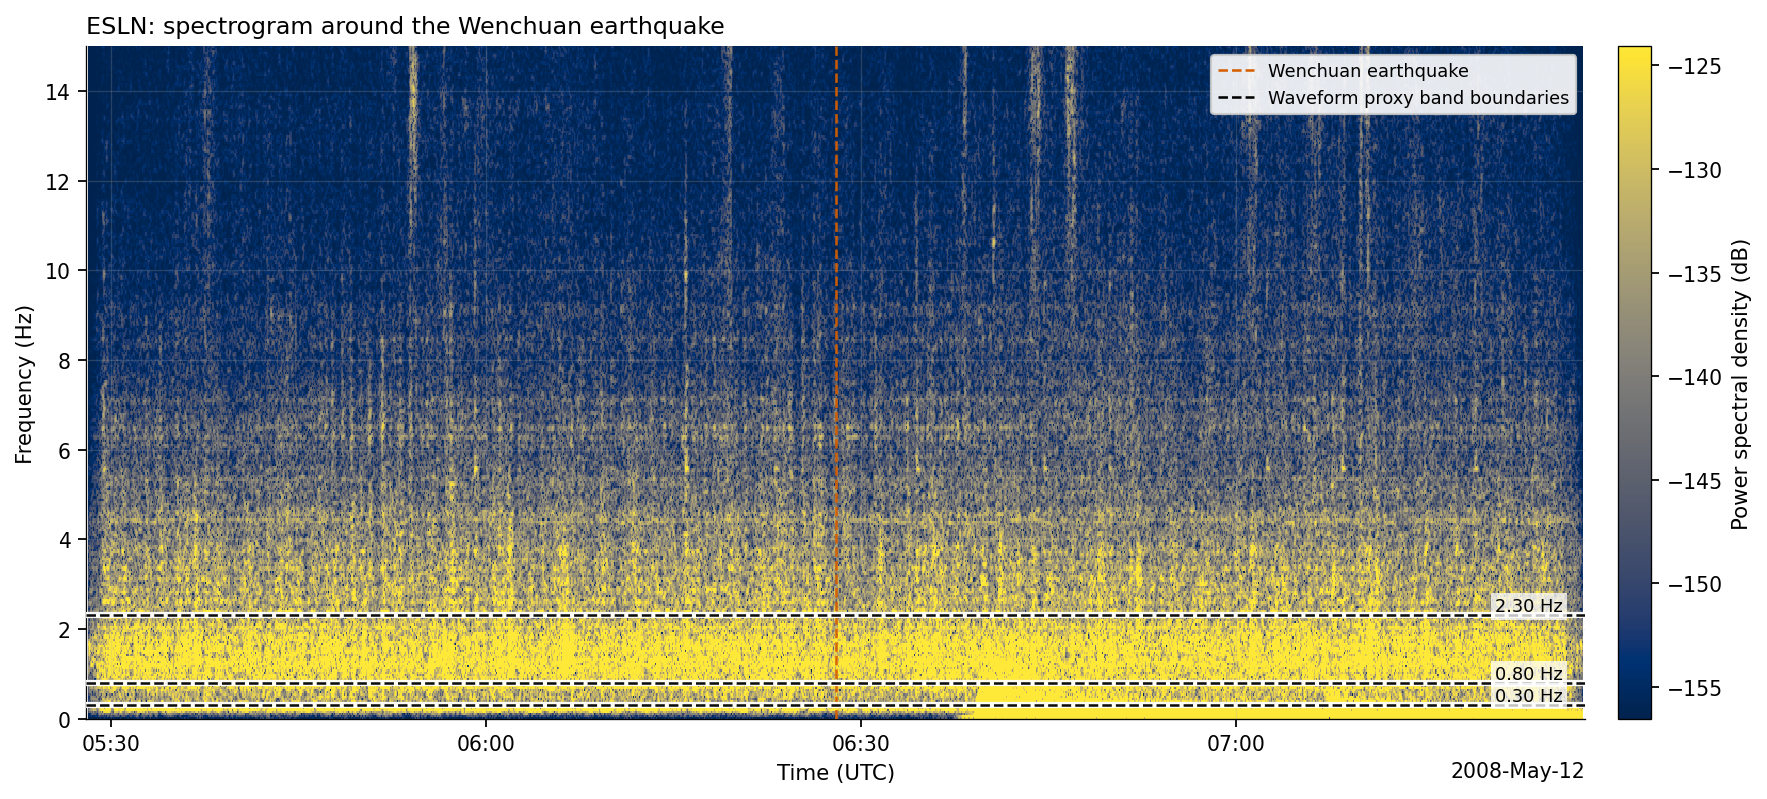

In [16]:
waveform_client = Client(
    base_url="https://webservices.ingv.it",
    service_mappings={
        "dataselect": "https://webservices.ingv.it/fdsnws/dataselect/1/",
        "station": "https://webservices.ingv.it/fdsnws/station/1/",
        "event": "https://webservices.ingv.it/fdsnws/event/1/",
    },
    _discover_services=False,
)

results = {}

results[ETNA_STATION] = run_teleseismic_checks(
    client=waveform_client,
    station=ETNA_STATION,
    cfg=ETNA_WAVEFORM_CONFIG,
    event_time=ETNA_EVENT_TIME,
)

## Final hourly dataset with event marker

The final dataset is plotted with the teleseismic event time marked. This provides a visual check that the causal-analysis dataset aligns with the known event window.

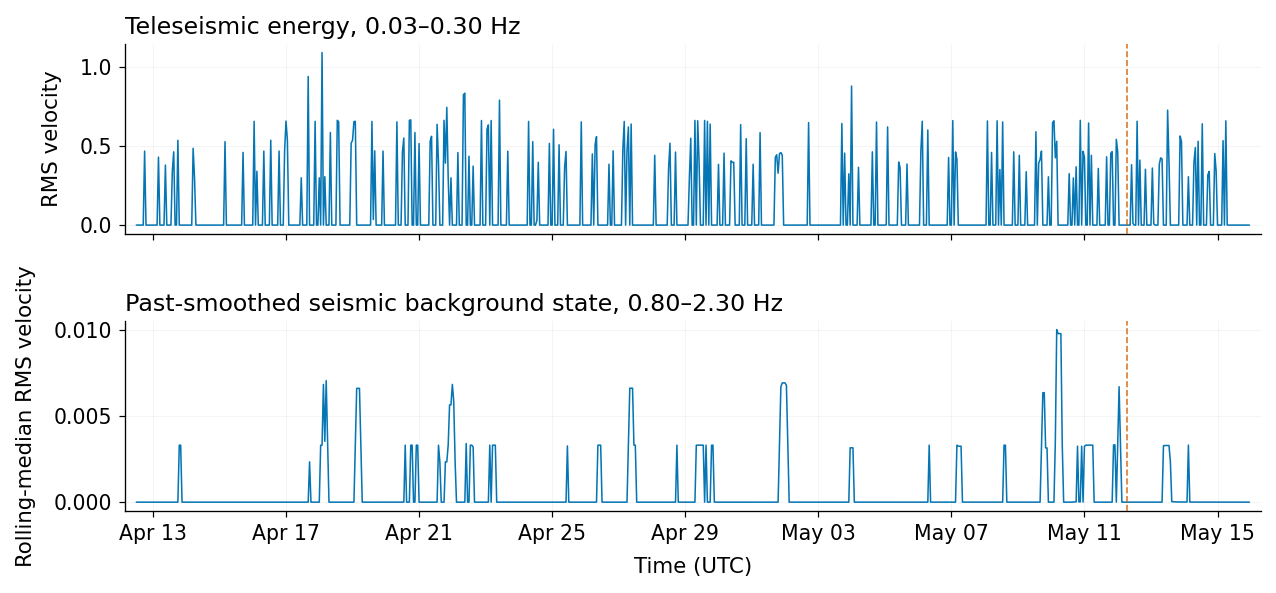

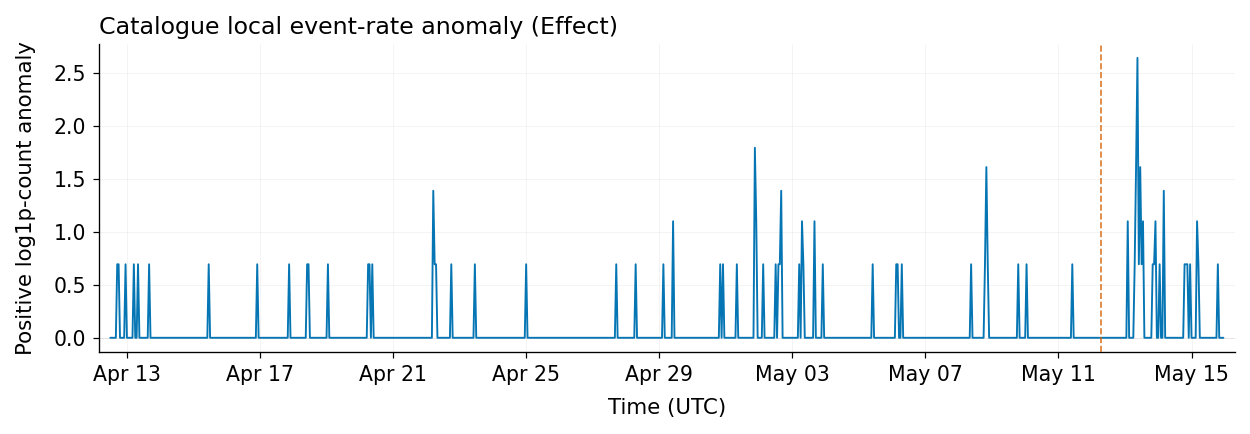

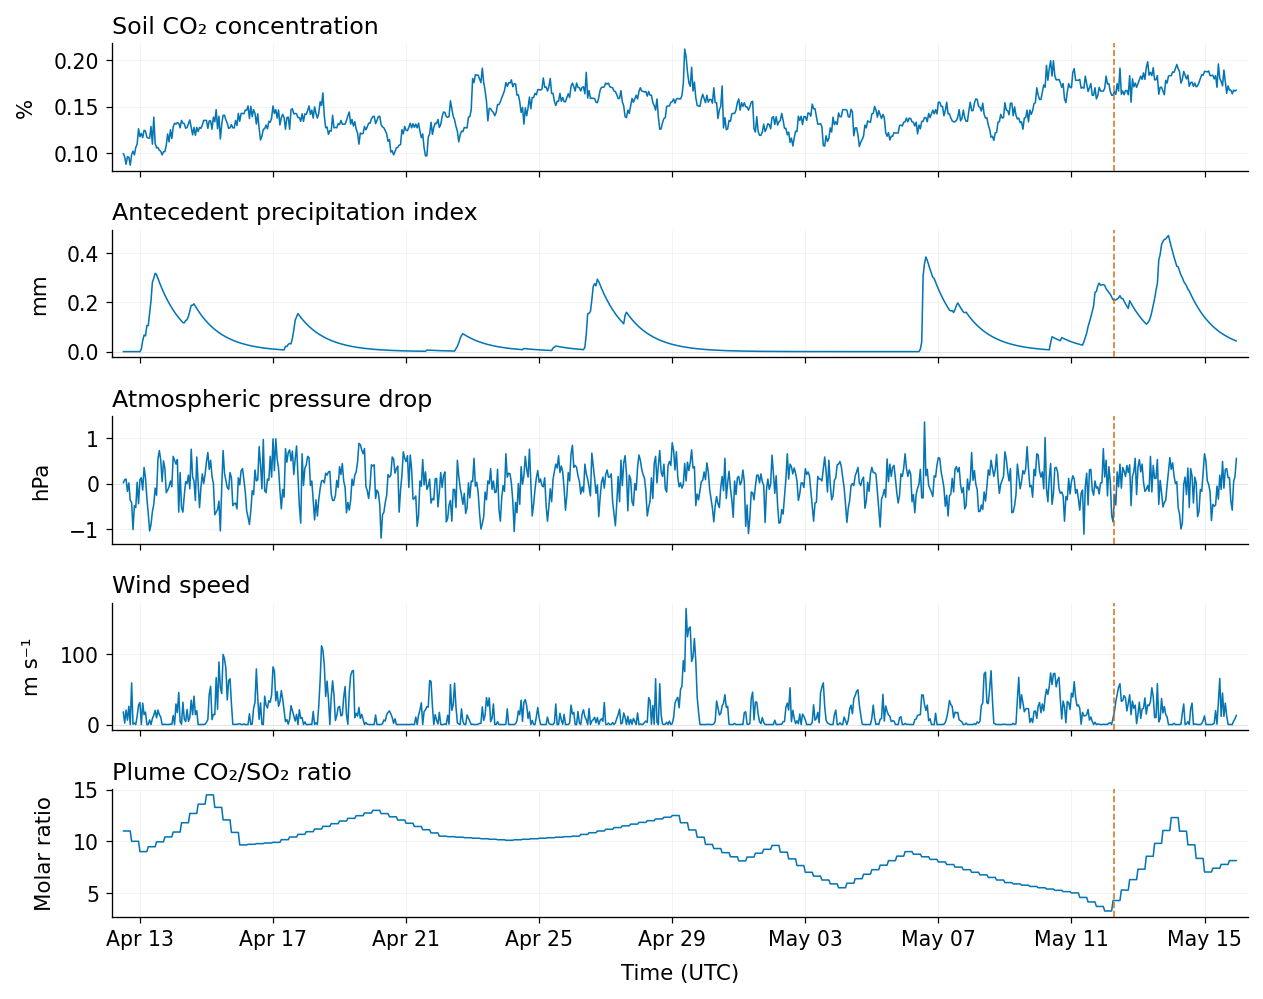

((<Figure size 1280x521.6 with 2 Axes>,
  array([<Axes: title={'left': 'Teleseismic energy, 0.03–0.30 Hz'}, ylabel='RMS velocity'>,
         <Axes: title={'left': 'Past-smoothed seismic background state, 0.80–2.30 Hz'}, xlabel='Time (UTC)', ylabel='Rolling-median RMS velocity'>],
        dtype=object)),
 (<Figure size 1280x344 with 1 Axes>,
  [<Axes: title={'left': 'Catalogue local event-rate anomaly (Effect)'}, xlabel='Time (UTC)', ylabel='Positive log1p-count anomaly'>]),
 (<Figure size 1280x976 with 5 Axes>,
  array([<Axes: title={'left': 'Soil CO₂ concentration'}, ylabel='%'>,
         <Axes: title={'left': 'Antecedent precipitation index'}, ylabel='mm'>,
         <Axes: title={'left': 'Atmospheric pressure drop'}, ylabel='hPa'>,
         <Axes: title={'left': 'Wind speed'}, ylabel='m s⁻¹'>,
         <Axes: title={'left': 'Plume CO₂/SO₂ ratio'}, xlabel='Time (UTC)', ylabel='Molar ratio'>],
        dtype=object)))

In [17]:
plot_etna_thesis_figures(
    csv_path="../data/etna/etna_raw.csv",
    event_time=ETNA_EVENT_TIME,
    save_dir="figures",
    include_titles=False,
)

## Geographic Visualization

,Source,Source ID,Variables
0,ESLN,ESLN,"background_seismic, teleseismic"
1,ETNAGAS network,ETNAGAS_3,"CO2_3, WindSpeed, pressure_drop"
2,EtnaSC catalogue,EtnaSC_2000_2010,local_event_rate_anomaly
3,"INGV-PA, Multi-GAS",ETNA_SUMMIT_PLUME,CO2_SO2
4,Open-Meteo,ETNA_OPENMETEO_PROXY,API


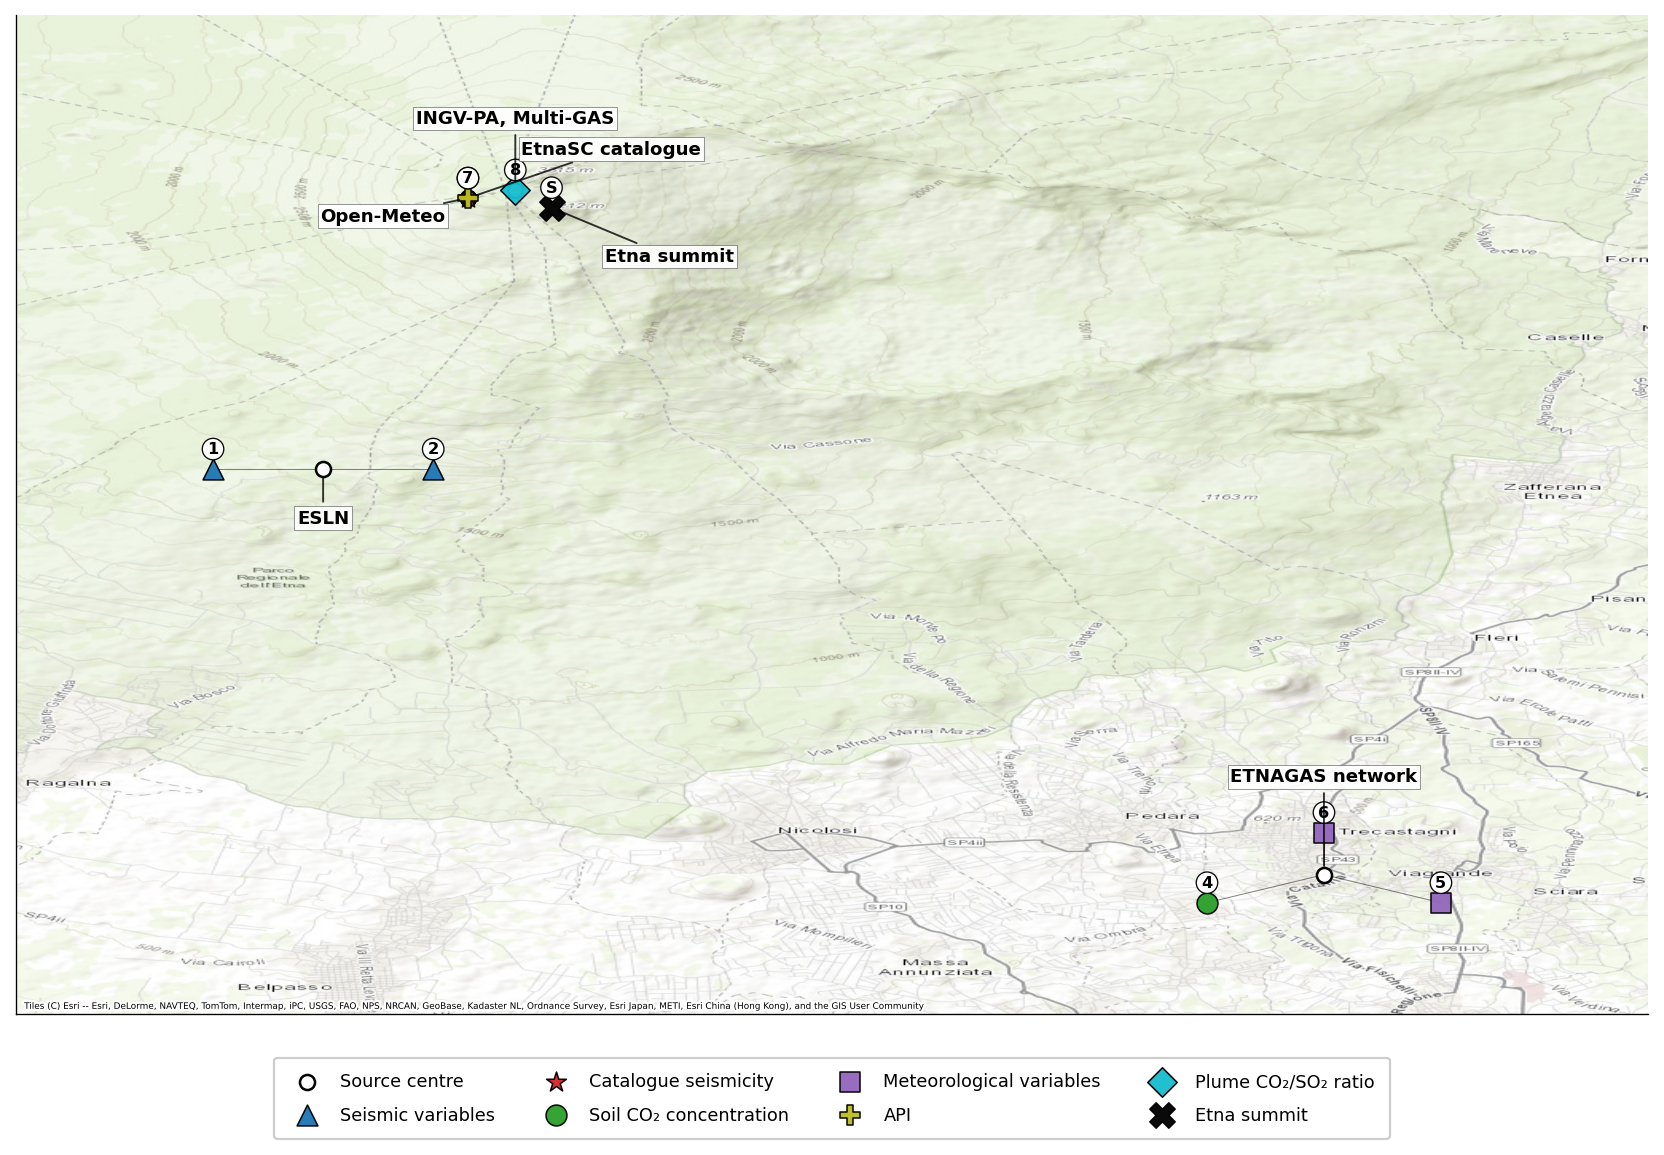

In [18]:
etna_meta = etna_observable_metadata()

fig, ax, etna_variable_table = plot_etna_all_variables_map(
    metadata=etna_meta,
    satellite=False, # True for satellite imagery
    save_dir="figures",
    filename="etna_map",
)

etna_variable_table